In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from rapidfuzz import fuzz
from rapidfuzz import distance
from src.similarity_matrix import (
    create_sim_m_heatmap,
    create_sim_m,
    create_slices
)

## Load used data

Moving record formats metadata

In [2]:
book_migration_directions = pd.read_csv(
    "outputs/csv/book_migration_direction_info.csv"
)

## Duplicate filtering

In [34]:
jsonls = tuple(
    Path("outputs/json/all_migration_events_parish_splits").glob("*.jsonl")
)
threshold = 0.8

for parish_jsonl in tqdm(jsonls):
    parish_df = pd.read_json(parish_jsonl, lines=True)
    parish_df["duplicate"] = False
    parish_df["is_ap"] = parish_df["book_source"].str.contains("ap")
    p_id = parish_df.loc[0, "parish_id"]

    for (year, direction), group in parish_df.groupby(
        ["year_prediction", "in/out"]
    ):
        events_ap = group[group["is_ap"]]
        events_other = group[~group["is_ap"]]

        other_sizes = (
            events_other.groupby("book_source")
            .size()
            .sort_values(ascending=False)
        )

        source_order = (["__ap__"] if not events_ap.empty else []) + list(
            other_sizes.index
        )

        source_frames = {"__ap__": events_ap}
        source_frames.update(
            {
                src: events_other[events_other["book_source"] == src]
                for src in other_sizes.index
            }
        )

        for i, ref_src in enumerate(source_order[:-1]):
            reference = source_frames[ref_src]
            if reference.empty:
                continue

            for cand_src in source_order[i + 1 :]:
                candidate = source_frames[cand_src]
                if candidate.empty:
                    continue

                sim_m = (
                    create_sim_m(
                        reference["row_data"].to_list(),
                        candidate["row_data"].to_list(),
                        distance.Levenshtein.normalized_similarity,
                        join_char="|",
                        n_workers=-1,
                    )[0]
                    * 100
                )

                duplicates = np.where(sim_m >= threshold)

                duplicate_pages = parish_df.loc[
                    candidate.iloc[duplicates[1]].index, "page_n"
                ].unique()
                parish_df.loc[
                    parish_df["page_n"].isin(duplicate_pages)
                    & (parish_df["book_source"] == cand_src),
                    "duplicate",
                ] = True

    with open(
        f"outputs/json/all_migration_events_parish_splits_duplicate_info/{p_id}_migration_events.jsonl",
        "w",
    ) as fp:
        rows_to_write = []
        for line in parish_df[
            [
                "row_data",
                "row_columns",
                "year_prediction",
                "book_year_start",
                "book_year_end",
                "duplicate",
                "page_n",
                "file_row",
                "in/out",
                "side",
                "parish_id",
                "book_id",
                "print_type",
                "book_source",
                "file_path",
            ]
        ].to_dict(orient="records"):
            rows_to_write.append(json.dumps(line, ensure_ascii=False) + "\n")

        fp.writelines(rows_to_write)

  0%|          | 0/468 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Duplicate filtering')

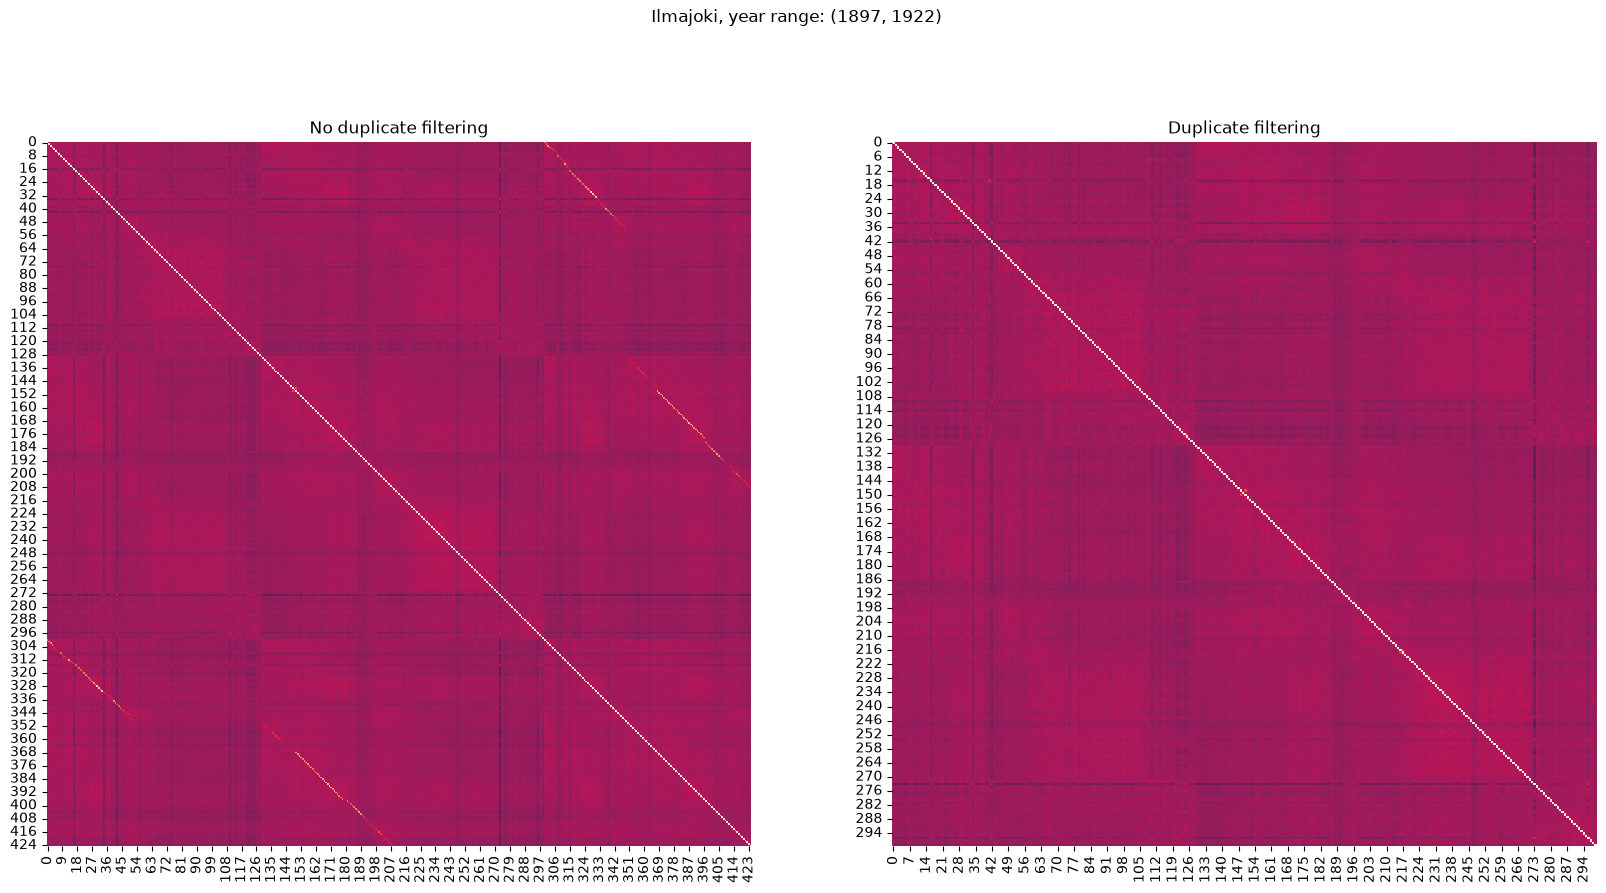

In [35]:
parish = "Ilmajoki"
p_id = 115
years = (1897, 1922)

df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/{p_id}_migration_events.jsonl",
    lines=True
)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f"{parish}, year range: {years}")

row_data = df[df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 20, 20)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0],
    xlabel="", ylabel="", ax=axs[0], cbar=False,
    vmin=0, vmax=1
)
axs[0].set_title("No duplicate filtering")

row_data = df[(~df["duplicate"]) & df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 20, 20)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0], xlabel="", ylabel="", ax=axs[1], cbar=False,
    vmin=0, vmax=1
)
axs[1].set_title("Duplicate filtering")

Text(0.5, 1.0, 'Duplicate filtering')

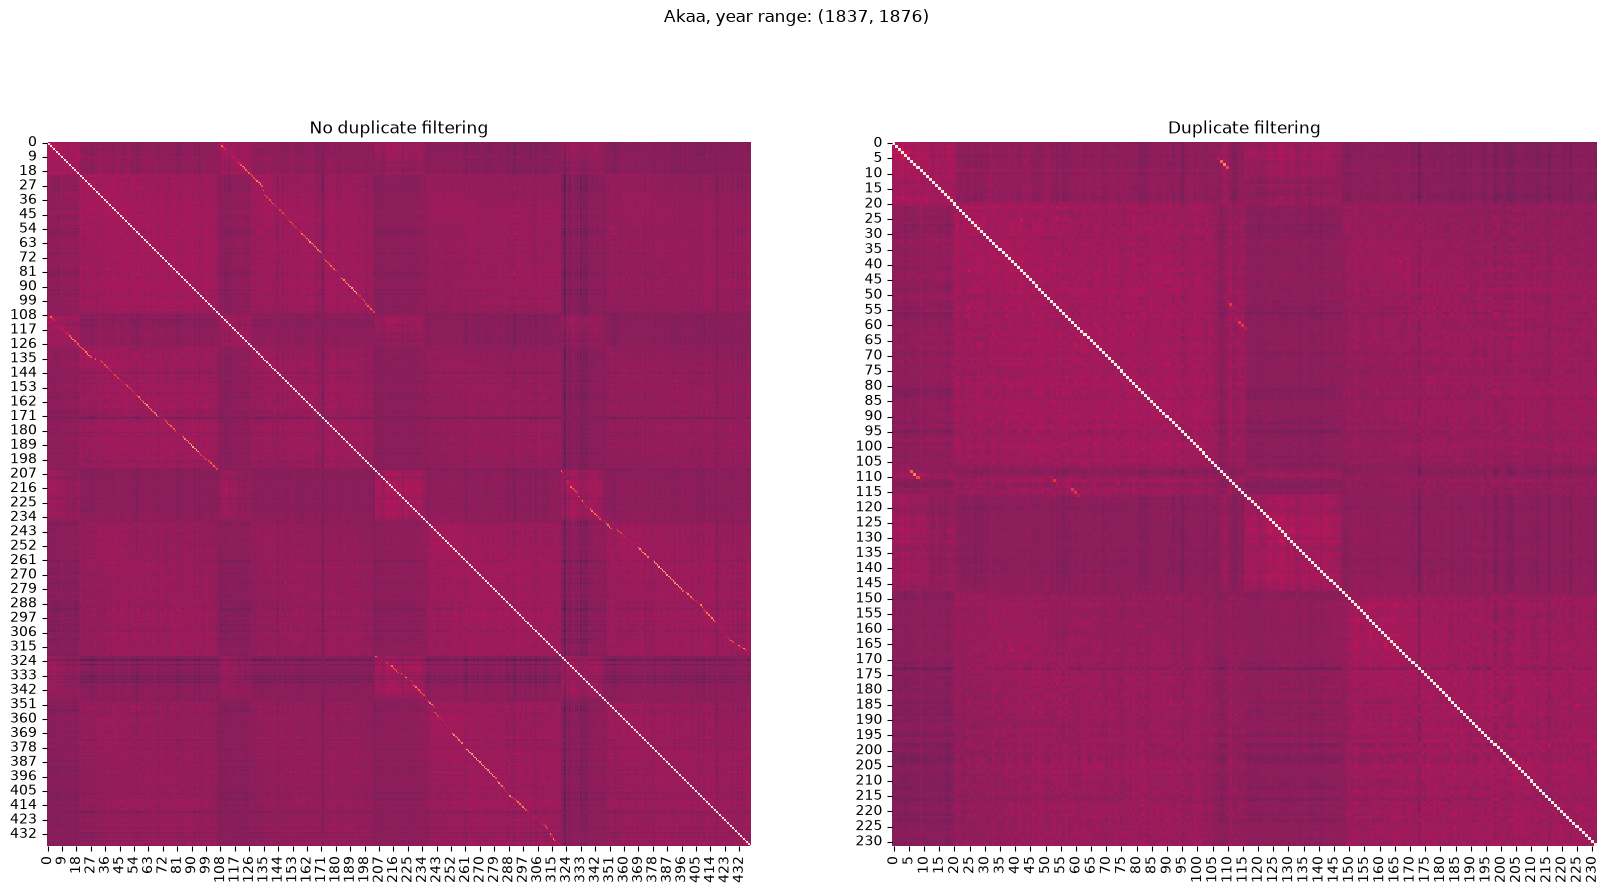

In [36]:
parish = "Akaa"
p_id = 3
years = (1837, 1876)

df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/{p_id}_migration_events.jsonl",
    lines=True
)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f"{parish}, year range: {years}")

row_data = df[df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 20, 20)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0],
    xlabel="", ylabel="", ax=axs[0], cbar=False,
    vmin=0, vmax=1
)
axs[0].set_title("No duplicate filtering")

row_data = df[(~df["duplicate"]) & df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 20, 20)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0], xlabel="", ylabel="", ax=axs[1], cbar=False,
    vmin=0, vmax=1
)
axs[1].set_title("Duplicate filtering")

Text(0.5, 1.0, 'Duplicate filtering')

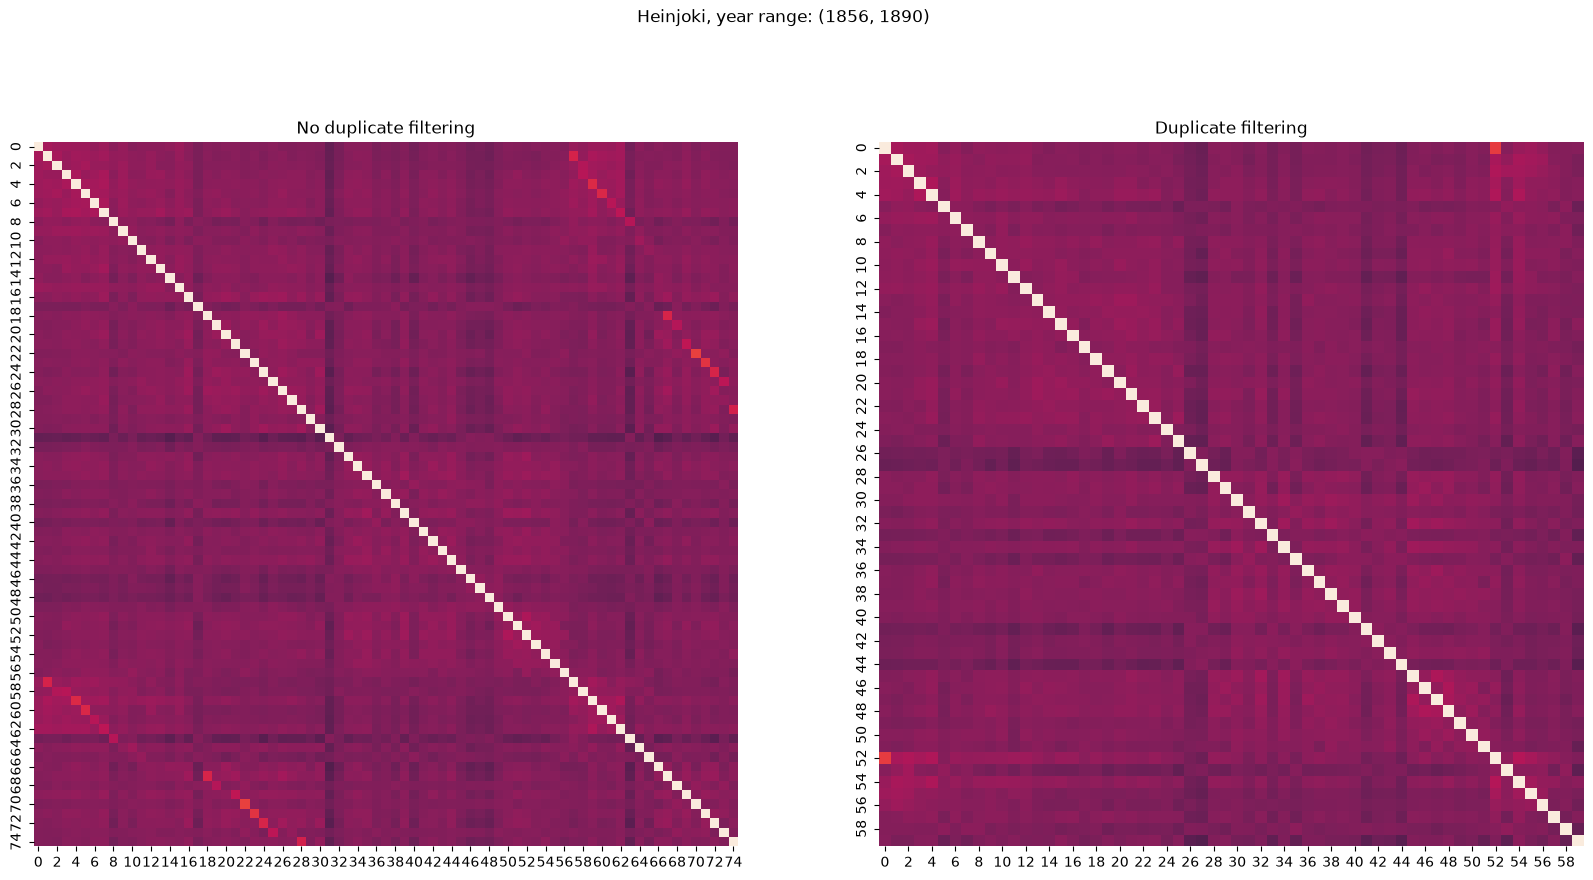

In [37]:
parish = "Heinjoki"
p_id = 68
years = (1856, 1890)

df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/{p_id}_migration_events.jsonl",
    lines=True
)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f"{parish}, year range: {years}")

row_data = df[df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 20, 20)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0],
    xlabel="", ylabel="", ax=axs[0], cbar=False,
    vmin=0, vmax=1
)
axs[0].set_title("No duplicate filtering")

row_data = df[(~df["duplicate"]) & df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 20, 20)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0], xlabel="", ylabel="", ax=axs[1], cbar=False,
    vmin=0, vmax=1
)
axs[1].set_title("Duplicate filtering")

Text(0.5, 1.0, 'Duplicate filtering')

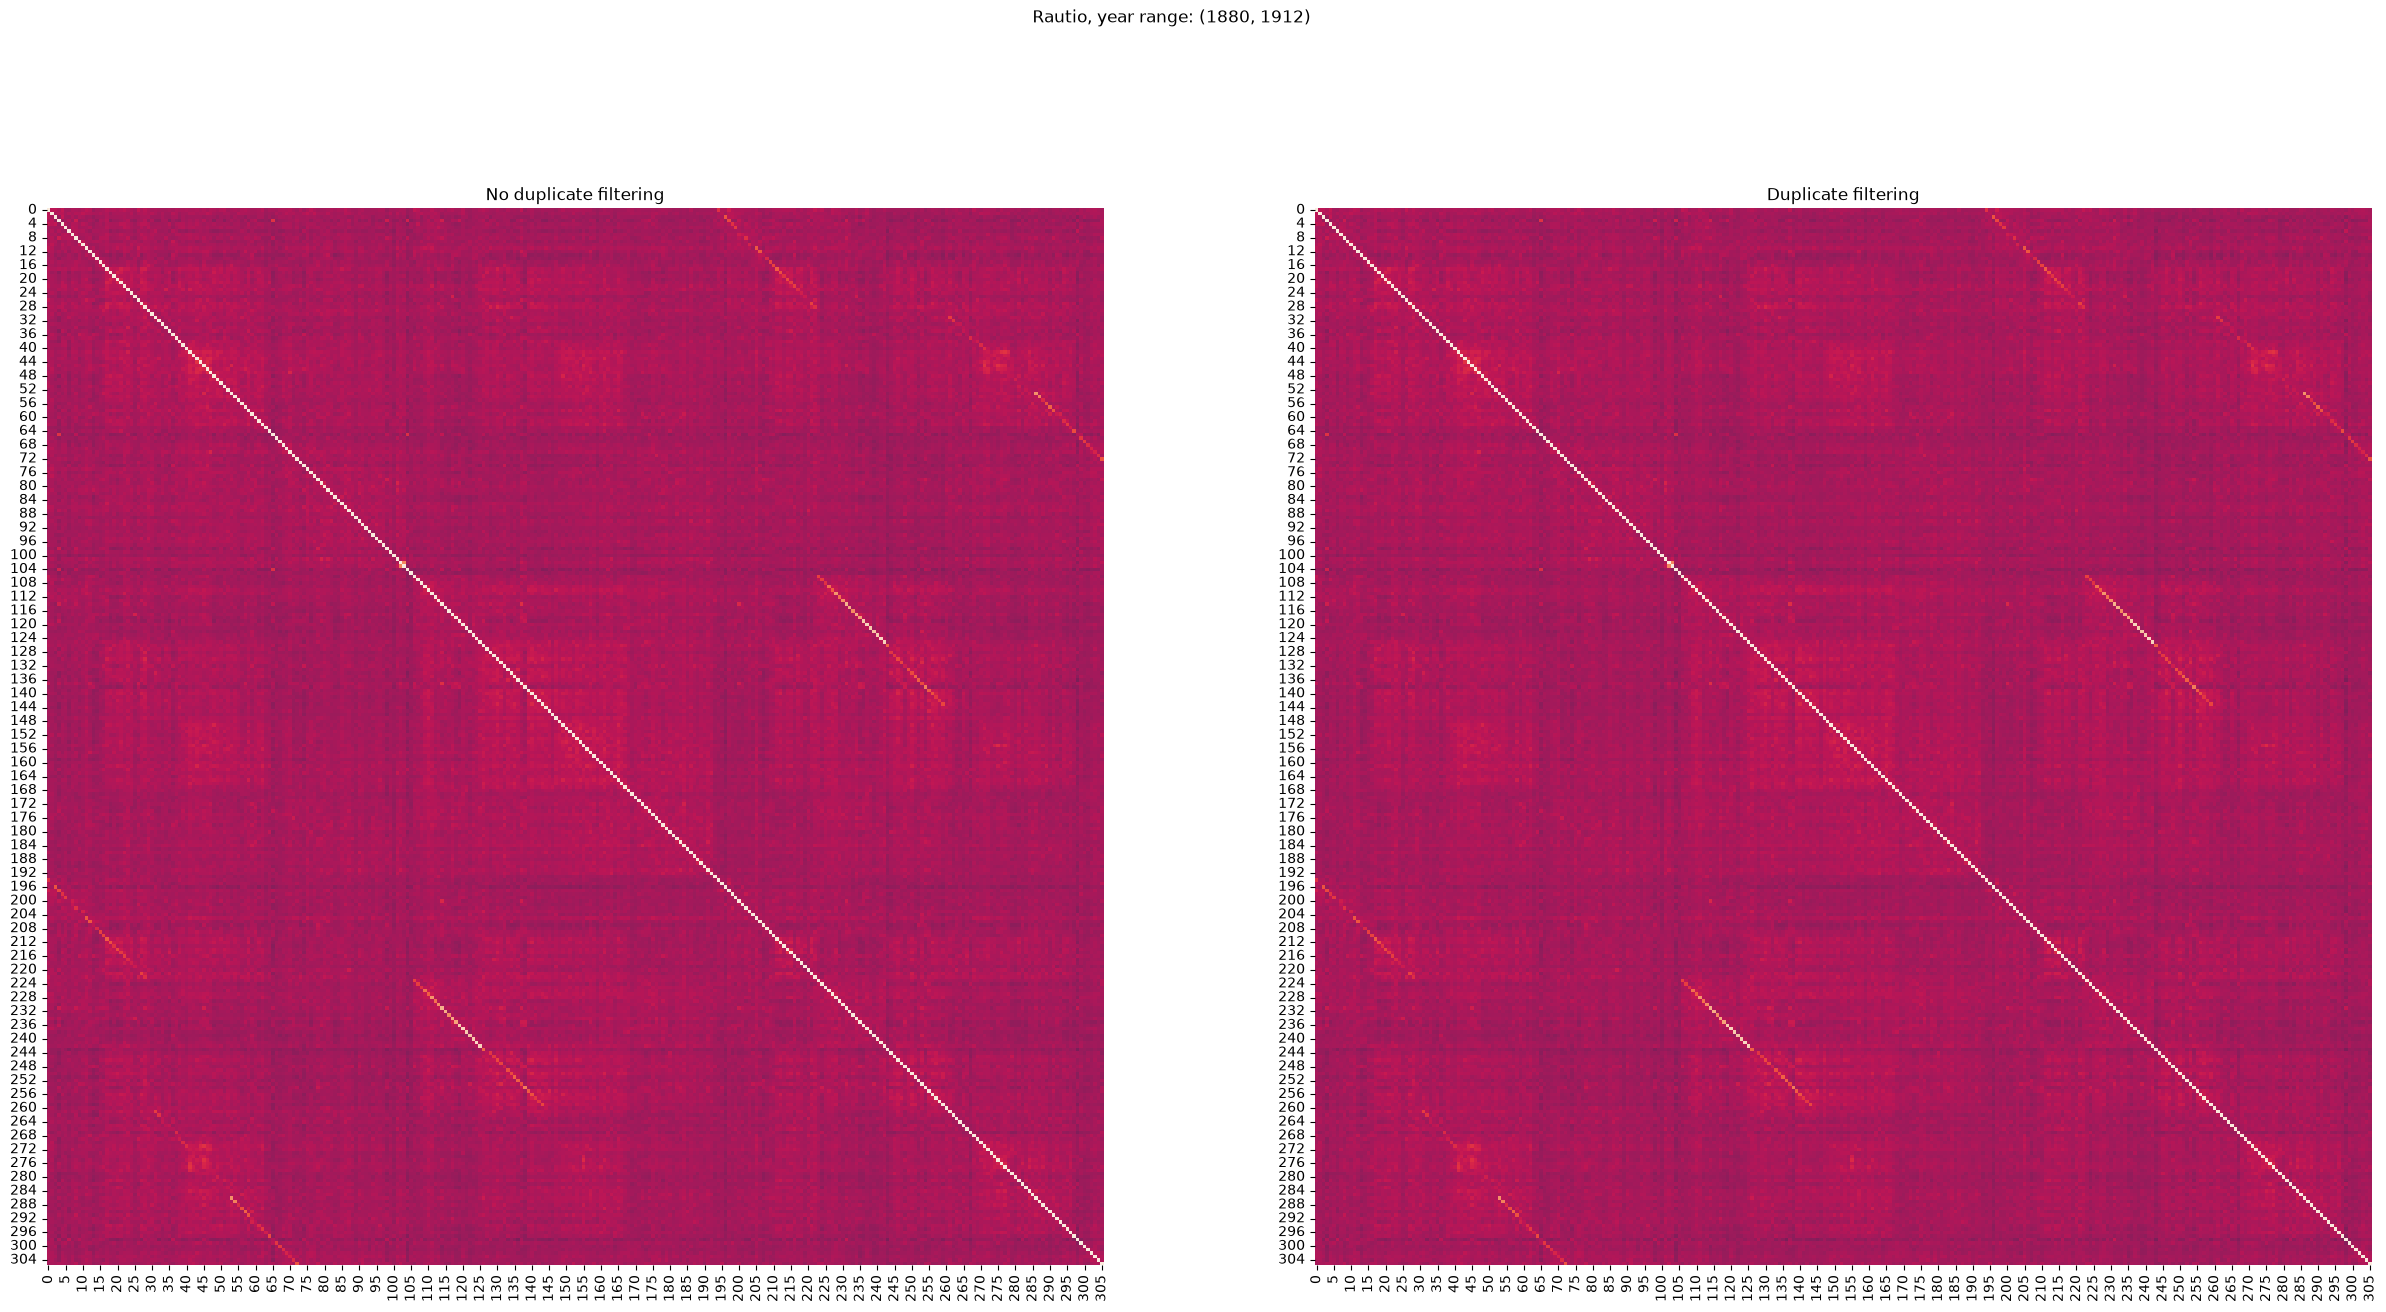

In [38]:
parish = "Rautio"
p_id = 447
years = (1880, 1912)

df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/{p_id}_migration_events.jsonl",
    lines=True
)

fig, axs = plt.subplots(1, 2, figsize=(30, 15))
fig.suptitle(f"{parish}, year range: {years}")

row_data = df[df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 10, 10)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0],
    xlabel="", ylabel="", ax=axs[0], cbar=False,
    vmin=0, vmax=1
)
axs[0].set_title("No duplicate filtering")

row_data = df[(~df["duplicate"]) & df["year_prediction"].isin(range(*years))]["row_data"].tolist()
slices = create_slices([",".join(x) for x in row_data], 10, 10)[0]
create_sim_m_heatmap(
    create_sim_m(
        slices, slices,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0], xlabel="", ylabel="", ax=axs[1], cbar=False,
    vmin=0, vmax=1
)
axs[1].set_title("Duplicate filtering")

In [39]:
total_non_duplicate_events = 0
for file_path in Path("outputs/json/all_migration_events_parish_splits_duplicate_info").glob("*.jsonl"):
    with open(file_path, "r") as fp:
        non_duplicate_events = sum(
            1 for line in fp if "duplicate\": false" in line
        )
        total_non_duplicate_events += non_duplicate_events

f"Total non-duplicate events: {total_non_duplicate_events}"

'Total non-duplicate events: 5555908'